## UNDERSTANDING ARTIFICIAL INTELLIGENCE
### PORTFOLIO OF WORK (SUMMATIVE ASSESSMENT)

### COMPONENT ONE: Predicting Customer Spending Behaviour in Streaming Services 

The goal of this exercise is to explore how supervised learning models can predict customer
spending and behaviour patterns in streaming services based on information in this dataset.  classification algorithms and unsupervised learning techniques are also required to be applied to determine
customer churn and identify clustering patterns in customer behaviour, respectively.
You will write up your analysis in the style of a scientific report, addressing the following
questions:
* (a) Compare regression models that predict "Monthly Spend" based on a single numerical
input feature. Based on your results, which numerical variable in the dataset is the best predictor
of Monthly Spend and why? For each numerical input feature, does Monthly Spend fit better
with a linear model or a non-linear model (e.g., polynomial regression)?
* (b) Consider regression models that take multiple numerical variables as input features to
predict "Monthly Spend". Does including multiple features improve prediction accuracy
compared to single-variable models from part (a)?
* (c) In parts (a) and (b), you only considered numerical variables as input. However, several
categorical variables (e.g., Gender, Region, Payment_Method) might also affect Monthly
Spend. Now train a regression model that uses both categorical and numerical variables (e.g.,
a Random Forest Regressor). Does this improve the model’s performance?
* (d) Develop an Artificial Neural Network (ANN) model to predict Monthly Spend based
on all available features in the dataset. How does its performance compare to other supervised
learning models? Discuss your neural network architecture, hyperparameter tuning, and
optimization choices. 
* (e) Based on your results, what is the best model for predicting Monthly Spend, and why?
Use evaluation metrics and visualizations to support your conclusions.
* (f) Train, evaluate and compare classification models to predict whether a customer will
churn (1) or not churn (0) based on available features. Which model performs best, and why?
Use appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, AUC-ROC) to
justify your findings.
* (g) Apply the k-Means clustering algorithm to identify different clusters in the streaming
service dataset. What is the optimal number of clusters (k) and why? Which features produce
the most meaningful clusters? Support your answer with visualizations and evaluation metrics.
* (h) Compare the k-Means clustering results from part (g) with another clustering algorithm
(e.g., Hierarchical Clustering or DBSCAN). Which algorithm provides the best segmentation
of customer behaviour, and why? Use evaluation metrics to justify your answer. 

In [1]:
import warnings
warnings.filterwarnings('ignore')
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [2]:
# Define the name of the csv file containing the data.
filename = "Streaming.csv"

# Use Pandas to read in the dataset from the csv file.
df = pd.read_csv("Streaming.csv")

In [3]:
df

,Customer_ID,Age,Gender,Subscription_Length,Region,Payment_Method,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
0,CUST000001,56.0,Male,54,South,PayPal,0,9.0,6.42,319,62.11,1
1,CUST000002,69.0,Female,21,East,Debit Card,1,2.0,13.77,166,37.27,1
2,CUST000003,46.0,Female,49,East,PayPal,3,8.0,19.91,207,61.82,0
3,CUST000004,32.0,Male,47,West,Debit Card,3,1.0,13.39,108,40.96,1
4,CUST000005,60.0,Male,6,East,Credit Card,2,NaN,13.18,65,45.97,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST004996,24.0,Male,5,East,Debit Card,0,8.0,18.03,121,51.61,0
4996,CUST004997,66.0,Female,12,East,PayPal,3,5.0,5.84,192,36.32,0
4997,CUST004998,26.0,Female,1,East,Credit Card,2,8.0,6.76,354,42.07,1
4998,CUST004999,53.0,Female,44,South,Debit Card,1,10.0,5.95,31,60.09,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             5000 non-null   object 
 1   Age                     4500 non-null   float64
 2   Gender                  5000 non-null   object 
 3   Subscription_Length     5000 non-null   int64  
 4   Region                  5000 non-null   object 
 5   Payment_Method          5000 non-null   object 
 6   Support_Tickets_Raised  5000 non-null   int64  
 7   Satisfaction_Score      4500 non-null   float64
 8   Discount_Offered        5000 non-null   float64
 9   Last_Activity           5000 non-null   int64  
 10  Monthly_Spend           5000 non-null   float64
 11  Churned                 5000 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [5]:
df.isnull().sum()

Customer_ID                 0
Age                       500
Gender                      0
Subscription_Length         0
Region                      0
Payment_Method              0
Support_Tickets_Raised      0
Satisfaction_Score        500
Discount_Offered            0
Last_Activity               0
Monthly_Spend               0
Churned                     0
dtype: int64

In [6]:
df['Age'].unique()

array([56., 69., 46., 32., 60., 25., 38., 36., nan, 28., 41., 53., 57.,
       20., 39., 19., 61., 55., 50., 29., 42., 66., 44., 45., 33., 68.,
       54., 24., 26., 35., 21., 31., 67., 43., 64., 52., 34., 23., 59.,
       51., 27., 48., 65., 40., 62., 58., 18., 22., 30., 49., 47., 37.,
       63.])

In [7]:
# Handle missing values
# Fill numeric columns with median, categorical with mode
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)


In [8]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert target column (Monthly Spend) to numeric if needed
df['Monthly_Spend'] = pd.to_numeric(df['Monthly_Spend'], errors='coerce')

In [9]:
# Handle outliers (optional: clip extreme values)
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[col] = df[col].clip(lower, upper)


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             5000 non-null   object 
 1   Age                     5000 non-null   float64
 2   Gender                  5000 non-null   object 
 3   Subscription_Length     5000 non-null   int64  
 4   Region                  5000 non-null   object 
 5   Payment_Method          5000 non-null   object 
 6   Support_Tickets_Raised  5000 non-null   int64  
 7   Satisfaction_Score      5000 non-null   float64
 8   Discount_Offered        5000 non-null   float64
 9   Last_Activity           5000 non-null   int64  
 10  Monthly_Spend           5000 non-null   float64
 11  Churned                 5000 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


### EXERCISE 1a
Compare regression models that predict "Monthly Spend" based on a single numerical
input feature. Based on your results, which numerical variable in the dataset is the best predictor
of Monthly Spend and why? For each numerical input feature, does Monthly Spend fit better
with a linear model or a non-linear model (e.g., polynomial regression)? 

##### LINEAR REGRESSION FOR AGE

In [11]:
# Extract the input feature
x = df["Age"]
# Extract the output feature
y = df["Monthly_Spend"]
x = x.to_numpy().reshape(-1, 1)

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [13]:
print(f"There are {len(x_train)},data points in the training set.") 
print(f"There are {len(x_test)} data points in the testing set.")

There are 4000,data points in the training set.
There are 1000 data points in the testing set.


In [14]:
from sklearn.preprocessing import StandardScaler
# Create an instance of the Standard Scaler class
scale = StandardScaler()

# Fit the standard scaler to the input data that we have in x.
scale.fit(x_train)
x_train_scaled = scale.transform(x_train)
x_test_scaled = scale.transform(x_test)

In [15]:
from sklearn.linear_model import LinearRegression
# Create an instance of the model.
stream_linear = LinearRegression()

# Fit the model to the training data.
stream_linear.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
# Get the fit coefficients from the best-fit model.
gradient = stream_linear.coef_[0]
intercept = stream_linear.intercept_
print("gradient: ", gradient)
print("intercept: ", intercept)

gradient:  0.018173379543786897
intercept:  46.55165124999999


In [17]:
# Import the metrics from the sklearn library.
# Use the final, trained model to predict the outputs () for in the testing dataset.

stream_pred = stream_linear.predict(x_test_scaled)

# Calculate the mean absolute error
mean_abs = mean_absolute_error(y_test, stream_pred)

# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, stream_pred)

# The root mean squared error is just the square root of the mean squared errorthat we calculated above.
rms_error = np.sqrt(mean_squared)

# Calculate the R2 score
R2 = r2_score(y_test, stream_pred)


# Print the results of these metrics. 
print("Mean absolute error: ", mean_abs) 
print("Mean squared error: ",mean_squared) 
print("Root mean squared error: ",rms_error) 
print("R2: ", R2)

Mean absolute error:  7.6000000087059165
Mean squared error:  86.68252241579
Root mean squared error:  9.310344913900344
R2:  -0.0006256230969448051


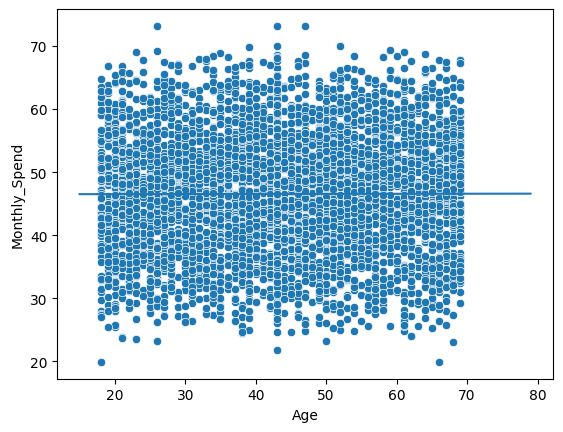

In [18]:
x_fit = np.arange(15, 80, 1).reshape(-1, 1)

# Apply the standardisation transformation using the same StandardScaler that we used on the training and testing data.
x_fit_scaled = scale.transform(x_fit)

# Apply the trained model to this scaled input array.
# This will give us the y-values for the best-fit line.
y_fit = stream_linear.predict(x_fit_scaled)

# Use seaborn to create a scatter plot of Life expectancy # versus Adult Mortality.
sns.scatterplot(data = df, x = "Age", y ="Monthly_Spend")

# Plot the best-fit line from the trained model 
plt.plot(x_fit, y_fit)

# Label both axes
plt.xlabel("Age") 
plt.ylabel("Monthly_Spend")

# Show the plot
plt.show()

##### POLYNOMIAL REGRESSION FOR AGE

In [19]:
# Import the Polynomial Features class from the sklearn library.

from sklearn.preprocessing import PolynomialFeatures

# Create an instance of the PolynomialFeatures class. 
poly = PolynomialFeatures(degree = 3, include_bias = False)
x_poly = poly.fit_transform(x_train_scaled)

# Create an instance of the LinearRegression model.
stream_poly = LinearRegression()

# Fit the model to the training data
stream_poly.fit(x_poly, y_train)

# Get the fit coefficients from the best-fit model.
coefficients = stream_poly.coef_ 
intercept = stream_poly.intercept_

print("intercept:", stream_poly.intercept_)
print("coefficients:", stream_poly.coef_)

x_test_poly = poly.fit_transform(x_test_scaled)
stream_pred = stream_poly.predict(x_test_poly)
# Calculate the mean absolute error

mean_abs = mean_absolute_error(y_test, stream_pred)
# Calculate the mean squared error

mean_squared = mean_squared_error(y_test, stream_pred)
# Calculate the root mean squared error

rms_error = np.sqrt(mean_squared)
# Calculate the R2 score

R2 = r2_score(y_test, stream_pred)

# Print the results of these metrics. 
print("Mean absolute error: ", mean_abs) 
print("Mean squared error: ", mean_squared) 
print("Root mean squared error: ",rms_error) 
print("R2: ", R2)

intercept: 46.54095125234849
coefficients: [-0.78599278  0.01102565  0.40201364]
Mean absolute error:  7.612431530718019
Mean squared error:  87.03003339524098
Root mean squared error:  9.328988873143809
R2:  -0.00463713984397951


##### LINEAR REGRESSION FOR SUBSCRIPTION LENGTH

In [20]:
# Extract the input feature
x = df["Subscription_Length"]
# Extract the output feature
y = df["Monthly_Spend"]
x = x.to_numpy().reshape(-1, 1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
# Create an instance of the StandardScaler class
scale = StandardScaler()
# Fit the standard scaler to the input data that we have in x.
scale.fit(x_train)
x_train_scaled = scale.transform(x_train)
x_test_scaled = scale.transform(x_test)
# Create an instance of the model.
stream_linear = LinearRegression()

# Fit the model to the training data.
stream_linear.fit(x_train_scaled, y_train)
# Get the fit coefficients from the best-fit model.
gradient = stream_linear.coef_[0]
intercept = stream_linear.intercept_
print("gradient: ", gradient)
print("intercept: ", intercept)

gradient:  5.248323141537495
intercept:  46.55165124999999


In [21]:
# Import the metrics from the sklearn library.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use the final, trained model to predict the outputs () for in # the testing dataset.
stream_pred = stream_linear.predict(x_test_scaled)

# Calculate the mean absolute error
mean_abs = mean_absolute_error(y_test, stream_pred)

# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, stream_pred)

# The root mean squared error is just the square root of the mean squared errorthat we calculated above.
rms_error = np.sqrt(mean_squared)

# Calculate the R2 score
R2 = r2_score(y_test, stream_pred)

# Print the results of these metrics. 
print("Mean absolute error: ", mean_abs) 
print("Mean squared error: ",mean_squared) 
print("Root mean squared error: ",rms_error) 
print("R2: ", R2)

Mean absolute error:  6.602671918683236
Mean squared error:  60.90027070635401
Root mean squared error:  7.803862550452436
R2:  0.2969935619776378


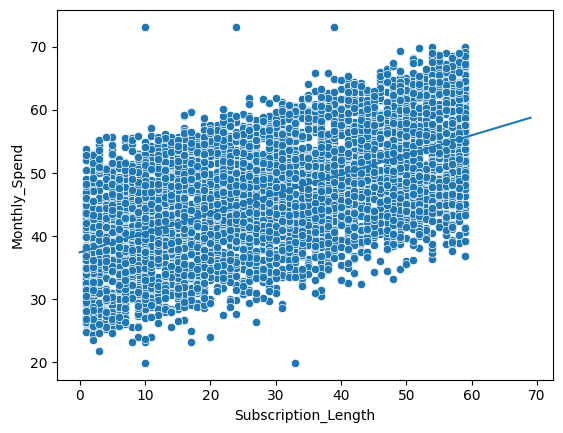

In [22]:

x_fit = np.arange(0, 70, 1).reshape(-1, 1)

# Apply the standardisation transformation using the same StandardScaler that we used on the training and testing data.
x_fit_scaled = scale.transform(x_fit)

# Apply the trained model to this scaled input array.
# This will give us the y-values for the best-fit line.
y_fit = stream_linear.predict(x_fit_scaled)

# Use seaborn to create a scatter plot of Life expectancy # versus Adult Mortality.
sns.scatterplot(data = df, x = "Subscription_Length", y ="Monthly_Spend")

# Plot the best-fit line from the trained model 
plt.plot(x_fit, y_fit)

# Label both axes
plt.xlabel("Subscription_Length") 
plt.ylabel("Monthly_Spend")

# Show the plot
plt.show()

##### POLYNOMIAL REGRESSION FOR SUBSCRIPTION LENGTH

In [23]:
# Extract the input feature
x = df["Subscription_Length"]

# Extract the output feature
y = df["Monthly_Spend"]

# Since we only have a single input feature, # we need to re-shape x so that it has 2 dimensions.
x = x.to_numpy().reshape(-1, 1)

# Split the x and y data between the training and testing datasets.
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

# Create an instance of the StandardScaler class
scale = StandardScaler()

# Fit the standard scaler to the input data that # we have in x_train.
scale.fit(x_train)

# Now apply the standard scaler transformation to both the training and the testing sets. 
x_train_scaled = scale.transform(x_train) 
x_test_scaled = scale.transform(x_test)

# Create an instance of the PolynomialFeatures class. 
poly = PolynomialFeatures(degree = 2, include_bias = False)
x_poly = poly.fit_transform(x_train_scaled)

# Create an instance of the LinearRegression model.
stream_poly = LinearRegression()

# Fit the model to the training data
stream_poly.fit(x_poly, y_train)

# Get the fit coefficients from the # best-fit model.
coefficients = stream_poly.coef_ 
intercept = stream_poly.intercept_

#Print the coefficients print("coefficients: ", coefficients) print("intercept: ", intercept)
print("intercept:", stream_poly.intercept_)
print("coefficients:", stream_poly.coef_)

x_test_poly = poly.fit_transform(x_test_scaled)
stream_pred = stream_poly.predict(x_test_poly)
# Calculate the mean absolute error
mean_abs = mean_absolute_error(y_test, stream_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, stream_pred)
# Calculate the root mean squared error
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, stream_pred)

# Print the results of these metrics. 
print("Mean absolute error: ", mean_abs) 
print("Mean squared error: ", mean_squared) 
print("Root mean squared error: ",rms_error) 
print("R2: ", R2)

intercept: 46.4347287767764
coefficients: [5.24157597 0.11692247]
Mean absolute error:  6.605258286546794
Mean squared error:  60.96616827077594
Root mean squared error:  7.808083520991302
R2:  0.2962328689379963


##### LINEAR REGRESSION FOR SUPPORT TICKET RAISED

In [24]:
# Extract the input feature
x = df["Support_Tickets_Raised"]
# Extract the output feature
y = df["Monthly_Spend"]
x = x.to_numpy().reshape(-1, 1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
# Create an instance of the StandardScaler class
scale = StandardScaler()
# Fit the standard scaler to the input data that we have in x.
scale.fit(x_train)
x_train_scaled = scale.transform(x_train)
x_test_scaled = scale.transform(x_test)
# Create an instance of the model.
stream_linear = LinearRegression()

# Fit the model to the training data.
stream_linear.fit(x_train_scaled, y_train)
# Get the fit coefficients from the best-fit model.
gradient = stream_linear.coef_[0]
intercept = stream_linear.intercept_
print("gradient: ", gradient)
print("intercept: ", intercept)

stream_pred = stream_linear.predict(x_test_scaled)
# Calculate the mean absolute error
mean_abs = mean_absolute_error(y_test, stream_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, stream_pred)
# The root mean squared error is just the square root of the mean squared errorthat we calculated above.
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, stream_pred)

# Print the results of these metrics. 
print("Mean absolute error: ", mean_abs) 
print("Mean squared error: ", mean_squared) 
print("Root mean squared error: ",rms_error) 
print("R2: ", R2)

gradient:  -1.5621923574978485
intercept:  46.55165124999999
Mean absolute error:  7.561318290270537
Mean squared error:  84.85520206787325
Root mean squared error:  9.211688339705878
R2:  0.020468174254282934


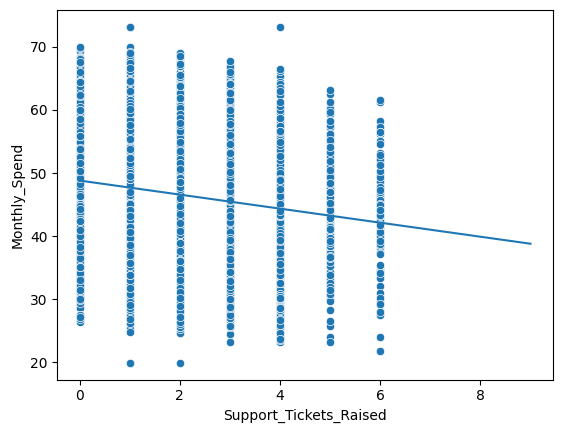

In [25]:
x_fit = np.arange(0, 10, 1).reshape(-1, 1)

# Apply the standardisation transformation using the same StandardScaler that we used on the training and testing data.
x_fit_scaled = scale.transform(x_fit)

# Apply the trained model to this scaled input array.
# This will give us the y-values for the best-fit line.
y_fit = stream_linear.predict(x_fit_scaled)

# Use seaborn to create a scatter plot of Life expectancy # versus Adult Mortality.
sns.scatterplot(data = df, x = "Support_Tickets_Raised", y ="Monthly_Spend")

# Plot the best-fit line from the trained model 
plt.plot(x_fit, y_fit)

# Label both axes
plt.xlabel("Support_Tickets_Raised") 
plt.ylabel("Monthly_Spend")

# Show the plot
plt.show()

##### POLYNOMIAL REGRESSION FOR SUPPORT TICKET RAISED

In [26]:
# Extract the input feature
x = df["Support_Tickets_Raised"]

# Extract the output feature
y = df["Monthly_Spend"]

# Since we only have a single input feature, # we need to re-shape x so that it has 2 dimensions.
x = x.to_numpy().reshape(-1, 1)

# Split the x and y data between the training and testing datasets.
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

# Create an instance of the StandardScaler class
scale = StandardScaler()

# Fit the standard scaler to the input data that # we have in x_train.
scale.fit(x_train)

# Now apply the standard scaler transformation to both the training and the testing sets. 
x_train_scaled = scale.transform(x_train) 
x_test_scaled = scale.transform(x_test)

# Create an instance of the PolynomialFeatures class. 
poly = PolynomialFeatures(degree = 2, include_bias = False)
x_poly = poly.fit_transform(x_train_scaled)

# Create an instance of the LinearRegression model.
stream_poly = LinearRegression()

# Fit the model to the training data
stream_poly.fit(x_poly, y_train)

# Get the fit coefficients from the # best-fit model.
coefficients = stream_poly.coef_ 
intercept = stream_poly.intercept_

#Print the coefficients print("coefficients: ", coefficients) print("intercept: ", intercept)
print("intercept:", stream_poly.intercept_)
print("coefficients:", stream_poly.coef_)

x_test_poly = poly.fit_transform(x_test_scaled)
stream_pred = stream_poly.predict(x_test_poly)
# Calculate the mean absolute error
mean_abs = mean_absolute_error(y_test, stream_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, stream_pred)
# Calculate the root mean squared error
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, stream_pred)

# Print the results of these metrics. 
print("Mean absolute error: ", mean_abs) 
print("Mean squared error: ", mean_squared) 
print("Root mean squared error: ",rms_error) 
print("R2: ", R2)

intercept: 46.32955666805956
coefficients: [-1.70058718  0.22209458]
Mean absolute error:  7.56630068597925
Mean squared error:  84.98548071557789
Root mean squared error:  9.218757004910039
R2:  0.01896429377869646


##### LINEAR REGRESSION FOR SATISFACTION SCORE

In [27]:
# Extract the input feature
x = df["Satisfaction_Score"]
# Extract the output feature
y = df["Monthly_Spend"]
x = x.to_numpy().reshape(-1, 1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
# Create an instance of the StandardScaler class
scale = StandardScaler()
# Fit the standard scaler to the input data that we have in x.
scale.fit(x_train)
x_train_scaled = scale.transform(x_train)
x_test_scaled = scale.transform(x_test)
# Create an instance of the model.
stream_linear = LinearRegression()

# Fit the model to the training data.
stream_linear.fit(x_train_scaled, y_train)
# Get the fit coefficients from the best-fit model.
gradient = stream_linear.coef_[0]
intercept = stream_linear.intercept_
print("gradient: ", gradient)
print("intercept: ", intercept)


stream_pred = stream_linear.predict(x_test_scaled)
# Calculate the mean absolute error
mean_abs = mean_absolute_error(y_test, stream_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, stream_pred)
# The root mean squared error is just the square root of the mean squared errorthat we calculated above.
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, stream_pred)

# Print the results of these metrics. 
print("Mean absolute error: ", mean_abs) 
print("Mean squared error: ",mean_squared) 
print("Root mean squared error: ",rms_error) 
print("R2: ", R2)

gradient:  6.826151929121801
intercept:  46.55165124999999
Mean absolute error:  5.120255283149872
Mean squared error:  38.78767693595095
Root mean squared error:  6.227975348052603
R2:  0.5522517997763183


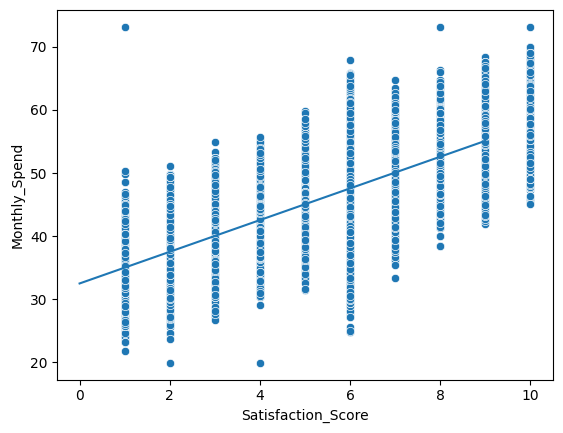

In [28]:
x_fit = np.arange(0, 10, 1).reshape(-1, 1)

# Apply the standardisation transformation using the same StandardScaler that we used on the training and testing data.
x_fit_scaled = scale.transform(x_fit)

# Apply the trained model to this scaled input array.
# This will give us the y-values for the best-fit line.
y_fit = stream_linear.predict(x_fit_scaled)

# Use seaborn to create a scatter plot of Life expectancy # versus Adult Mortality.
sns.scatterplot(data = df, x = "Satisfaction_Score", y ="Monthly_Spend")

# Plot the best-fit line from the trained model 
plt.plot(x_fit, y_fit)

# Label both axes
plt.xlabel("Satisfaction_Score") 
plt.ylabel("Monthly_Spend")

# Show the plot
plt.show()

##### POLYNOMIAL REGRESSION FOR SATISFACTION SCORE

In [29]:
# Extract the input feature
x = df["Satisfaction_Score"]

# Extract the output feature
y = df["Monthly_Spend"]

# Since we only have a single input feature, # we need to re-shape x so that it has 2 dimensions.
x = x.to_numpy().reshape(-1, 1)

# Split the x and y data between the training and testing datasets.
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

# Create an instance of the StandardScaler class
scale = StandardScaler()

# Fit the standard scaler to the input data that # we have in x_train.
scale.fit(x_train)

# Now apply the standard scaler transformation to both the training and the testing sets. 
x_train_scaled = scale.transform(x_train) 
x_test_scaled = scale.transform(x_test)

# Create an instance of the PolynomialFeatures class. 
poly = PolynomialFeatures(degree = 2, include_bias = False)
x_poly = poly.fit_transform(x_train_scaled)

# Create an instance of the LinearRegression model.
stream_poly = LinearRegression()

# Fit the model to the training data
stream_poly.fit(x_poly, y_train)

# Get the fit coefficients from the # best-fit model.
coefficients = stream_poly.coef_ 
intercept = stream_poly.intercept_

#Print the coefficients print("coefficients: ", coefficients) print("intercept: ", intercept)
print("intercept:", stream_poly.intercept_)
print("coefficients:", stream_poly.coef_)

x_test_poly = poly.fit_transform(x_test_scaled)
stream_pred = stream_poly.predict(x_test_poly)
# Calculate the mean absolute error
mean_abs = mean_absolute_error(y_test, stream_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, stream_pred)
# Calculate the root mean squared error
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, stream_pred)

# Print the results of these metrics. 
print("Mean absolute error: ", mean_abs) 
print("Mean squared error: ", mean_squared) 
print("Root mean squared error: ",rms_error) 
print("R2: ", R2)

intercept: 46.43634091325742
coefficients: [6.83607232 0.11531034]
Mean absolute error:  5.120730739068736
Mean squared error:  38.77773289051865
Root mean squared error:  6.227176959948918
R2:  0.552366589544538


##### LINEAR REGRESSION FOR DISCOUNT OFFERED

In [30]:
# Extract the input feature
x = df["Discount_Offered"]
# Extract the output feature
y = df["Monthly_Spend"]
x = x.to_numpy().reshape(-1, 1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
# Create an instance of the StandardScaler class
scale = StandardScaler()
# Fit the standard scaler to the input data that we have in x.
scale.fit(x_train)
x_train_scaled = scale.transform(x_train)
x_test_scaled = scale.transform(x_test)
# Create an instance of the model.
stream_linear = LinearRegression()

# Fit the model to the training data.
stream_linear.fit(x_train_scaled, y_train)
# Get the fit coefficients from the best-fit model.
gradient = stream_linear.coef_[0]
intercept = stream_linear.intercept_
print("gradient: ", gradient)
print("intercept: ", intercept)


stream_pred = stream_linear.predict(x_test_scaled)
# Calculate the mean absolute error
mean_abs = mean_absolute_error(y_test, stream_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, stream_pred)
# The root mean squared error is just the square root of the mean squared errorthat we calculated above.
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, stream_pred)

# Print the results of these metrics. 
print("Mean absolute error: ", mean_abs) 
print("Mean squared error: ",mean_squared) 
print("Root mean squared error: ",rms_error) 
print("R2: ", R2)

gradient:  2.0676606282674848
intercept:  46.55165124999999
Mean absolute error:  7.380826513828045
Mean squared error:  82.29845769973171
Root mean squared error:  9.071849739702026
R2:  0.04998212764617449


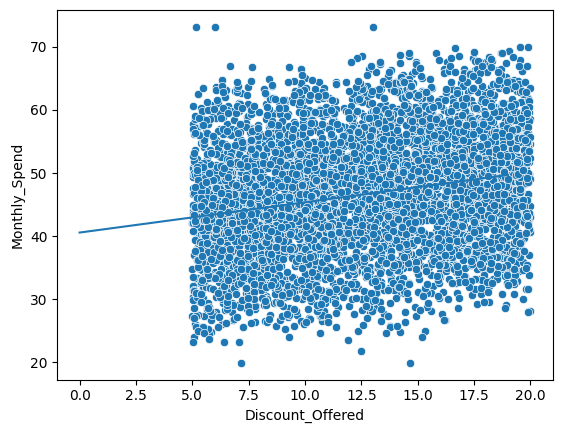

In [31]:
x_fit = np.arange(0, 20, 1).reshape(-1, 1)

# Apply the standardisation transformation using the same StandardScaler that we used on the training and testing data.
x_fit_scaled = scale.transform(x_fit)

# Apply the trained model to this scaled input array.
# This will give us the y-values for the best-fit line.
y_fit = stream_linear.predict(x_fit_scaled)

# Use seaborn to create a scatter plot of Life expectancy # versus Adult Mortality.
sns.scatterplot(data = df, x = "Discount_Offered", y ="Monthly_Spend")

# Plot the best-fit line from the trained model 
plt.plot(x_fit, y_fit)

# Label both axes
plt.xlabel("Discount_Offered") 
plt.ylabel("Monthly_Spend")

# Show the plot
plt.show()

##### POLYNOMIAL REGRESSION FOR DISCOUNT OFFERED

In [32]:
# Extract the input feature
x = df["Discount_Offered"]

# Extract the output feature
y = df["Monthly_Spend"]

# Since we only have a single input feature, # we need to re-shape x so that it has 2 dimensions.
x = x.to_numpy().reshape(-1, 1)

# Split the x and y data between the training and testing datasets.
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

# Create an instance of the StandardScaler class
scale = StandardScaler()

# Fit the standard scaler to the input data that # we have in x_train.
scale.fit(x_train)

# Now apply the standard scaler transformation to both the training and the testing sets. 
x_train_scaled = scale.transform(x_train) 
x_test_scaled = scale.transform(x_test)

# Create an instance of the PolynomialFeatures class. 
poly = PolynomialFeatures(degree = 2, include_bias = False)
x_poly = poly.fit_transform(x_train_scaled)

# Create an instance of the LinearRegression model.
stream_poly = LinearRegression()

# Fit the model to the training data
stream_poly.fit(x_poly, y_train)

# Get the fit coefficients from the # best-fit model.
coefficients = stream_poly.coef_ 
intercept = stream_poly.intercept_

#Print the coefficients print("coefficients: ", coefficients) print("intercept: ", intercept)
print("intercept:", stream_poly.intercept_)
print("coefficients:", stream_poly.coef_)

x_test_poly = poly.fit_transform(x_test_scaled)
stream_pred = stream_poly.predict(x_test_poly)
# Calculate the mean absolute error
mean_abs = mean_absolute_error(y_test, stream_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, stream_pred)
# Calculate the root mean squared error
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, stream_pred)

# Print the results of these metrics. 
print("Mean absolute error: ", mean_abs) 
print("Mean squared error: ", mean_squared) 
print("Root mean squared error: ",rms_error) 
print("R2: ", R2)

intercept: 46.58278275158192
coefficients: [ 2.0677599 -0.0311315]
Mean absolute error:  7.380850835246016
Mean squared error:  82.29353916800183
Root mean squared error:  9.071578648063513
R2:  0.050038905053427896


##### LINEAR REGRESSION FOR LAST ACTIVITY

In [33]:
# Extract the input feature
x = df["Last_Activity"]
# Extract the output feature
y = df["Monthly_Spend"]
x = x.to_numpy().reshape(-1, 1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
# Create an instance of the StandardScaler class
scale = StandardScaler()
# Fit the standard scaler to the input data that we have in x.
scale.fit(x_train)
x_train_scaled = scale.transform(x_train)
x_test_scaled = scale.transform(x_test)
# Create an instance of the model.
stream_linear = LinearRegression()

# Fit the model to the training data.
stream_linear.fit(x_train_scaled, y_train)
# Get the fit coefficients from the best-fit model.
gradient = stream_linear.coef_[0]
intercept = stream_linear.intercept_
print("gradient: ", gradient)
print("intercept: ", intercept)


stream_pred = stream_linear.predict(x_test_scaled)
# Calculate the mean absolute error
mean_abs = mean_absolute_error(y_test, stream_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, stream_pred)
# The root mean squared error is just the square root of the mean squared errorthat we calculated above.
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, stream_pred)

# Print the results of these metrics. 
print("Mean absolute error: ", mean_abs) 
print("Mean squared error: ",mean_squared) 
print("Root mean squared error: ",rms_error) 
print("R2: ", R2)

gradient:  0.003991445637973941
intercept:  46.55165124999999
Mean absolute error:  7.60085291923398
Mean squared error:  86.69084382542188
Root mean squared error:  9.310791793688756
R2:  -0.0007216818578792417


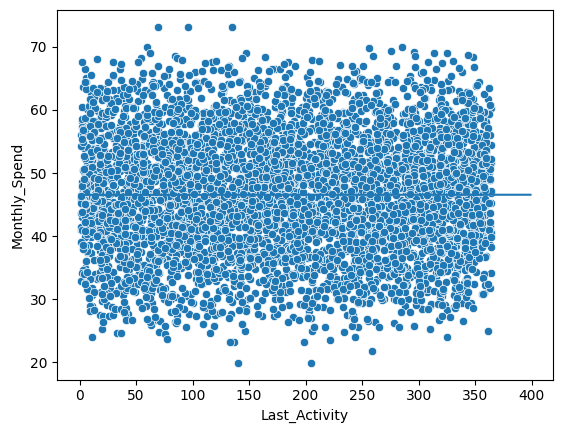

In [34]:
x_fit = np.arange(0, 400, 1).reshape(-1, 1)

# Apply the standardisation transformation using the same StandardScaler that we used on the training and testing data.
x_fit_scaled = scale.transform(x_fit)

# Apply the trained model to this scaled input array.
# This will give us the y-values for the best-fit line.
y_fit = stream_linear.predict(x_fit_scaled)

# Use seaborn to create a scatter plot of Life expectancy # versus Adult Mortality.
sns.scatterplot(data = df, x = "Last_Activity", y ="Monthly_Spend")

# Plot the best-fit line from the trained model 
plt.plot(x_fit, y_fit)

# Label both axes
plt.xlabel("Last_Activity") 
plt.ylabel("Monthly_Spend")

# Show the plot
plt.show()


##### POLYNOMIAL REGRESSION FOR LAST ACTIVITY

In [35]:
# Extract the input feature
x = df["Last_Activity"]

# Extract the output feature
y = df["Monthly_Spend"]

# Since we only have a single input feature, # we need to re-shape x so that it has 2 dimensions.
x = x.to_numpy().reshape(-1, 1)

# Split the x and y data between the training and testing datasets.
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

# Create an instance of the StandardScaler class
scale = StandardScaler()

# Fit the standard scaler to the input data that # we have in x_train.
scale.fit(x_train)

# Now apply the standard scaler transformation to both the training and the testing sets. 
x_train_scaled = scale.transform(x_train) 
x_test_scaled = scale.transform(x_test)

# Create an instance of the PolynomialFeatures class. 
poly = PolynomialFeatures(degree = 2, include_bias = False)
x_poly = poly.fit_transform(x_train_scaled)

# Create an instance of the LinearRegression model.
stream_poly = LinearRegression()

# Fit the model to the training data
stream_poly.fit(x_poly, y_train)

# Get the fit coefficients from the # best-fit model.
coefficients = stream_poly.coef_ 
intercept = stream_poly.intercept_

#Print the coefficients print("coefficients: ", coefficients) print("intercept: ", intercept)
print("intercept:", stream_poly.intercept_)
print("coefficients:", stream_poly.coef_)

x_test_poly = poly.fit_transform(x_test_scaled)
stream_pred = stream_poly.predict(x_test_poly)
# Calculate the mean absolute error
mean_abs = mean_absolute_error(y_test, stream_pred)
# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, stream_pred)
# Calculate the root mean squared error
rms_error = np.sqrt(mean_squared)
# Calculate the R2 score
R2 = r2_score(y_test, stream_pred)

# Print the results of these metrics. 
print("Mean absolute error: ", mean_abs) 
print("Mean squared error: ", mean_squared) 
print("Root mean squared error: ",rms_error) 
print("R2: ", R2)

intercept: 46.538735347451556
coefficients: [0.00387691 0.0129159 ]
Mean absolute error:  7.600310703308944
Mean squared error:  86.68642985076035
Root mean squared error:  9.310554755263531
R2:  -0.0006707288396361477


#### (B)MULTILINEAR REGRESSION
Consider regression models that take multiple numerical variables as input features to
predict "Monthly Spend". Does including multiple features improve prediction accuracy
compared to single-variable models from part (a)? 

In [36]:
# Extract the input features. Note that we do not need to reshape x in this example, because it is already a 2-dimensional array.

feature_names = ["Age","Subscription_Length","Support_Tickets_Raised","Satisfaction_Score","Discount_Offered","Last_Activity"] 
x = df[feature_names]
# Extract the output feature
y = df["Monthly_Spend"]

# Split the x and y data between the training and testing datasets.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2,random_state = 42)

# Create an instance of the StandardScaler class
scale = StandardScaler()

# Fit the standard scaler to the input data that we have inx_train 
scale.fit(x_train)

# Now apply the standard scaler transformation to both the training and the testing sets.
x_train_scaled = scale.transform(x_train)
x_test_scaled = scale.transform(x_test)

# Create an instance of the model
stream_linear = LinearRegression()

# Fit the model to the training data.
stream_linear.fit(x_train_scaled, y_train)

# Get the fit coefficients from the best-fit model.
intercept = stream_linear.intercept_ 
coefficients = stream_linear.coef_

# Print the coefficients.
print("coefficients: ",coefficients) 
print("intercept: ", intercept)


coefficients:  [ 0.02069829  5.15678018 -1.74878685  6.78002186  2.11740513 -0.05015139]
intercept:  46.55165124999999


In [37]:
# Use the final, trained model to predict the outputs (Monthly Spend) 
# the testing dataset.
stream_pred = stream_linear.predict(x_test_scaled)

# Calculate the mean absolute error
mean_abs = mean_absolute_error(y_test, stream_pred)

# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, stream_pred)

# Calculate the root mean squared error
rms_error = np.sqrt(mean_squared)

# Calculate the R2 score
R2 = r2_score(y_test, stream_pred)

# Print the results of these metrics. 
print("Mean absoluteerror: ", mean_abs) 
print("Mean squared error: ",mean_squared) 
print("Root mean squared error: ",rms_error) 
print("R2: ", R2)

Mean absoluteerror:  1.3179724899676026
Mean squared error:  6.380641160978295
Root mean squared error:  2.52599310390553
R2:  0.9263446325796018


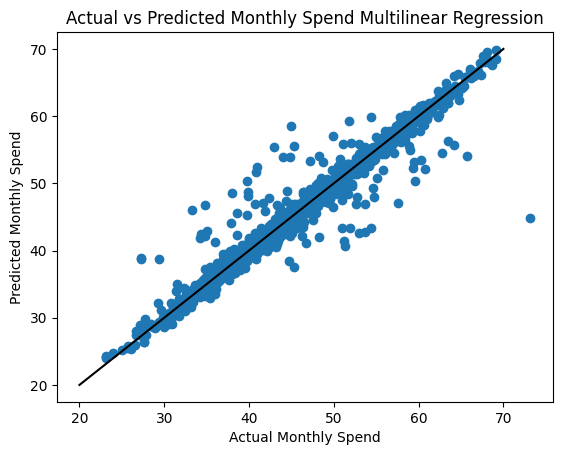

In [38]:
plt.scatter(y_test, stream_pred)
plt.plot([20, 70], [20, 70], 'k-')

plt.title('Actual vs Predicted Monthly Spend Multilinear Regression')

# Label both axes.
plt.xlabel("Actual Monthly Spend"), plt.ylabel("Predicted Monthly Spend")
plt.show()

#### (C) RANDOM FOREST REGRESSION
In parts (a) and (b), you only considered numerical variables as input. However, several
categorical variables (e.g., Gender, Region, Payment_Method) might also affect Monthly
Spend. Now train a regression model that uses both categorical and numerical variables (e.g.,
a Random Forest Regressor). Does this improve the model’s performance?

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Extract the categorical input feature
cat_feature = ["Gender","Region","Payment_Method"]
x_cat = df[cat_feature]


from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)

# fit the label encoder to the input data
x_cat_encoded = ohe.fit_transform(x_cat)

num_feature =["Age","Subscription_Length","Support_Tickets_Raised","Satisfaction_Score","Discount_Offered","Last_Activity"] 
x_num = df[num_feature]

# Create an instance of the StandardScaler class
scale = StandardScaler()

# Fit the standard scaler to the input data that # we have in x_num
scale.fit(x_num)

# Now apply the standard scaler transformation to x_num 
x_num_scaled = scale.transform(x_num)

# concatenate x_numerical with the x_cat_label array containing the label-encoded categorical data 

x_all = np.concatenate((x_num_scaled, x_cat_encoded), axis = 1)

y = df["Monthly_Spend"]


#Split into Training (to learn) and Testing (to check) sets
x_train, x_test, y_train, y_test = train_test_split(x_all, y, test_size=0.2, random_state=42)

In [40]:
from sklearn.ensemble import RandomForestRegressor

# Create an instance of the model
stream_linear = RandomForestRegressor()

# Fit the model to the training data.
stream_linear.fit(x_train, y_train)

# Use the final, trained model to predict the # outputs (life expectancies) for countries in # the testing dataset.
stream_pred = stream_linear.predict(x_test)

# Calculate the mean absolute error
mean_abs = mean_absolute_error(y_test, stream_pred)

# Calculate the mean squared error
mean_squared = mean_squared_error(y_test, stream_pred)

# Calculate the root mean squared error
rms_error = np.sqrt(mean_squared)

# Calculate the R2 score
R2 = r2_score(y_test, stream_pred)

# Print the results of these metrics. 
print("Mean absolute error: ", mean_abs) 
print("Mean squared error: ", mean_squared) 
print("Root mean squared error: ", rms_error)
print("R2: ", R2)


Mean absolute error:  1.7368952625000005
Mean squared error:  7.916862687628905
Root mean squared error:  2.813692002979165
R2:  0.9086111543710846


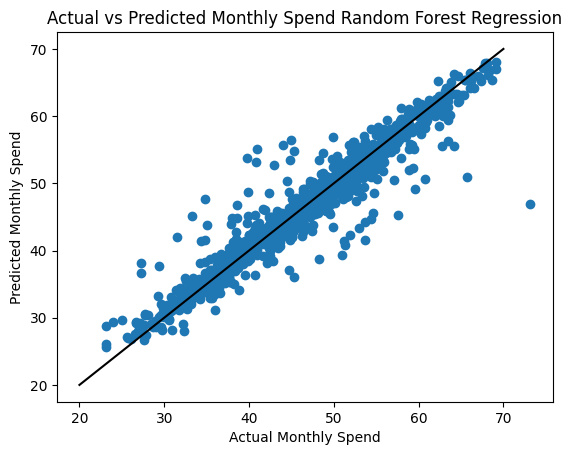

In [41]:
plt.scatter(y_test, stream_pred)
plt.plot([20, 70], [20, 70], 'k-')

plt.title('Actual vs Predicted Monthly Spend Random Forest Regression')

# Label both axes.
plt.xlabel("Actual Monthly Spend"), plt.ylabel("Predicted Monthly Spend")
plt.show()

#### (D) Artificial Neural Network (ANN) model 
Develop an Artificial Neural Network (ANN) model to predict Monthly Spend based
on all available features in the dataset. How does its performance compare to other supervised
learning models? Discuss your neural network architecture, hyperparameter tuning, and
optimization choices. 

In [42]:
# import the Sequential model from Keras
from tensorflow.keras.models import Sequential


# Also import the layers classes Dense (to create dense layers in the network) and Dropout (to impose a dropout rate on a layer)
from tensorflow.keras.layers import Dense, Dropout

# Build the Neural Network
#create an instance of the Sequential class, 
model = Sequential()

# Build layers in network
model.add(Dense(64, input_dim=x_train.shape[1], activation='relu')) 
model.add(Dropout(0.2))                             
model.add(Dense(64, activation='relu'))              
model.add(Dense(1, activation='linear')) 

# Compile (Setup the learning process)
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_squared_error'])

# Define early stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience = 20)

In [43]:
# Train the model
# Save fit function in variable (history)
history = model.fit(x = x_train, y = y_train,batch_size = None, epochs = 200, verbose = "auto", validation_split = 0.1, 
                    callbacks = [early_stopping])

Epoch 1/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 870us/step - loss: 1162.8340 - mean_squared_error: 1162.8340 - val_loss: 21.4693 - val_mean_squared_error: 21.4693
Epoch 2/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step - loss: 31.7086 - mean_squared_error: 31.7086 - val_loss: 12.3910 - val_mean_squared_error: 12.3910
Epoch 3/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 396us/step - loss: 27.2360 - mean_squared_error: 27.2360 - val_loss: 10.3399 - val_mean_squared_error: 10.3399
Epoch 4/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 396us/step - loss: 25.5774 - mean_squared_error: 25.5774 - val_loss: 9.8223 - val_mean_squared_error: 9.8223
Epoch 5/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step - loss: 24.6714 - mean_squared_error: 24.6714 - val_loss: 8.4853 - val_mean_squared_error: 8.4853
Epoch 6/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 413us/step - loss: 23.5186 - mean_squared_error: 23.5186 - val_loss: 7.9579 - val_mean_squared_error: 7.9579
Epoch 7/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 415us/step - loss: 23.1870 -

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 538us/step


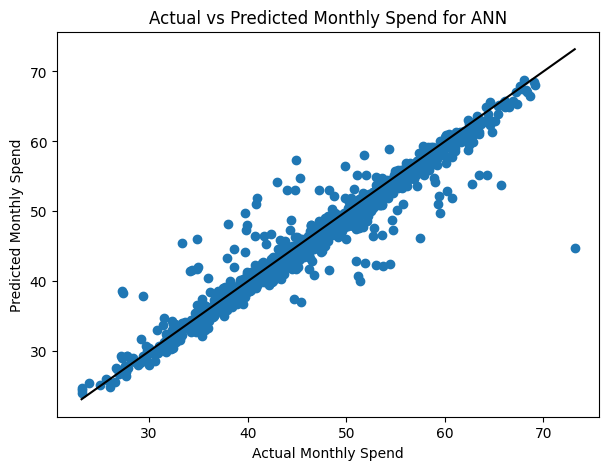


Mean Square Error: 6.731646001411663 
Mean Absolute Error: 1.4822713616943362 
Root Mean Square error 2.813692002979165 
R2 Score: 0.9222927842094775


In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Make Predictions
# We ask the model to predict life expectancy using the test data we held back
# Plot Predicted vs. Actual Life Expectancy

y_pred = model.predict(x_test)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred)          
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k-')    
plt.xlabel('Actual Monthly Spend')
plt.ylabel('Predicted Monthly Spend')
plt.title('Actual vs Predicted Monthly Spend for ANN')

plt.show()

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rms_error = np.sqrt(mean_squared)
R2  = r2_score(y_test, y_pred)
print("\nMean Square Error:", mse, "\nMean Absolute Error:", mae, "\nRoot Mean Square error",rms_error,"\nR2 Score:", R2)

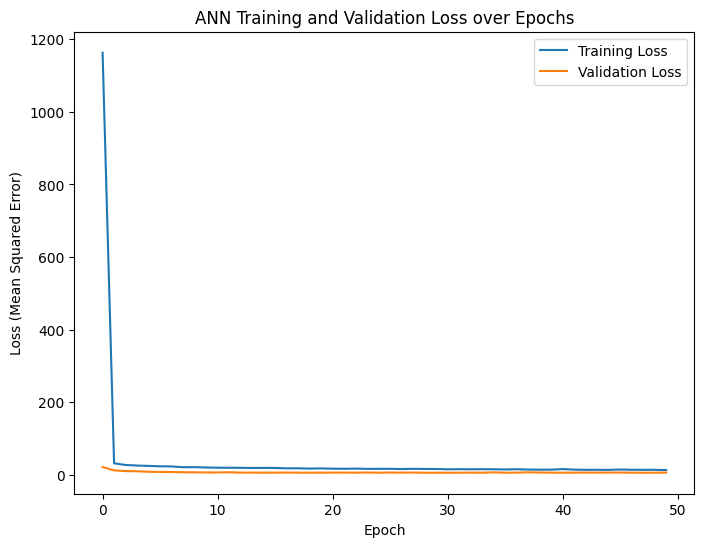

In [45]:
# First, we convert the history data into a Pandas DataFrame to make it easier to handle
history_df = pd.DataFrame(history.history) 

# Now we plot the losses
plt.figure(figsize=(8, 6))
plt.plot(history_df['loss'], label='Training Loss')      # Plot training error
plt.plot(history_df['val_loss'], label='Validation Loss') # Plot validation error
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.title('ANN Training and Validation Loss over Epochs')
plt.legend() # Show the labels
plt.show() 

#### (F) CLASSIFICATIONS
Train, evaluate and compare classification models to predict whether a customer will
churn (1) or not churn (0) based on available features. Which model performs best, and why?
Use appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, AUC-ROC) to
justify your findings.


##### RANDOM FOREST CLASSIFICATION

In [46]:
# Extract the categorical input feature
cat_feature = ["Gender","Region","Payment_Method"]

x_cat = df[cat_feature]


from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown="ignore")


# fit the label encoder to the input data
x_cat_encoded = ohe.fit_transform(x_cat).toarray()

# Extract the numerical input feature
num_feature = ["Age","Subscription_Length","Support_Tickets_Raised","Satisfaction_Score","Discount_Offered","Last_Activity","Monthly_Spend"] 

x_num = df[num_feature]
# Create an instance of the StandardScaler class
scale = StandardScaler()

# Fit the standard scaler to the input data that # we have in x_num
scale.fit(x_num)

# Now apply the standard scaler transformation to x_num 
x_num_scaled = scale.transform(x_num)

# concatenate x_numerical with the x_cat_label array containing the label-encoded categorical data 

x_all = np.concatenate((x_num_scaled, x_cat_encoded), axis = 1)

y = df["Churned"]


#Split into Training (to learn) and Testing (to check) sets
x_train, x_test, y_train, y_test = train_test_split(x_all, y, test_size=0.2, random_state=42)

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,RocCurveDisplay)

# Create an instance of the model
stream_class = RandomForestClassifier()

# Fit the model to the training data.
stream_class.fit(x_train, y_train)

# Use the trained model to predict the output class labels for the training set.
y_pred = stream_class.predict(x_test)

# Predict churn probability for ROC-AUC
y_prob_rf = stream_class.predict_proba(x_test)[:, 1]


In [48]:
print("\nClassification Report for Random Forest:\n", classification_report(y_test, y_pred ))


Classification Report for Random Forest:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       545
           1       1.00      0.97      0.98       455

    accuracy                           0.98      1000
   macro avg       0.99      0.98      0.98      1000
weighted avg       0.99      0.98      0.98      1000



In [49]:
print("RANDOM FOREST RESULTS")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred ))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

RANDOM FOREST RESULTS
Accuracy : 0.985
Precision: 1.0
Recall   : 0.967032967032967
F1-score : 0.9832402234636871
ROC-AUC  : 0.9989232785563061


In [50]:
num_feature_names = num_feature  

cat_feature_names = ohe.get_feature_names_out(cat_feature) 
all_feature_names = list(num_feature_names) + list(cat_feature_names)

importances = stream_class.feature_importances_

feature_importance_df = pd.DataFrame({"Feature": all_feature_names,"Importance": importances}).sort_values(by="Importance", ascending=False)

# Show top 10
feature_importance_df.head(10)


,Feature,Importance
3,Satisfaction_Score,0.371051
5,Last_Activity,0.318608
6,Monthly_Spend,0.139561
2,Support_Tickets_Raised,0.098072
1,Subscription_Length,0.028032
4,Discount_Offered,0.019037
0,Age,0.011614
14,Payment_Method_Debit Card,0.001805
10,Region_North,0.001733
8,Gender_Male,0.001670


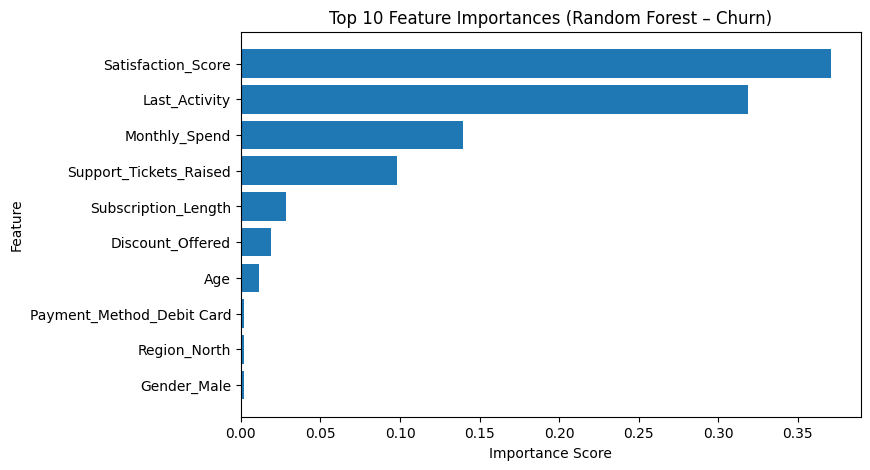

In [51]:
plt.figure(figsize=(8, 5))
plt.barh(feature_importance_df["Feature"].head(10),feature_importance_df["Importance"].head(10))
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances (Random Forest – Churn)")
plt.show()

<Figure size 1600x1200 with 0 Axes>

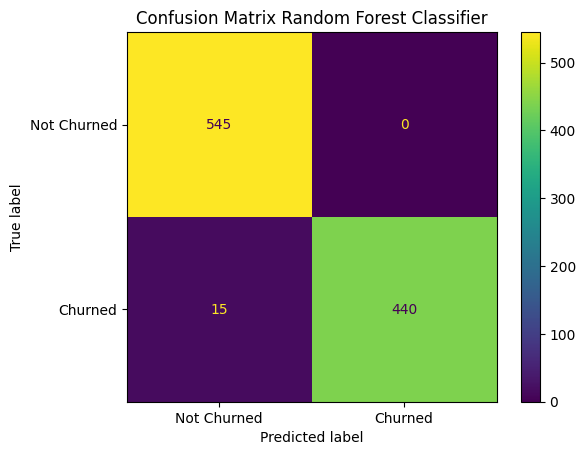

In [52]:
class_names = ['Not Churned', 'Churned']
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(dpi=200, figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred, display_labels=class_names)
plt.title('Confusion Matrix Random Forest Classifier')
plt.show()

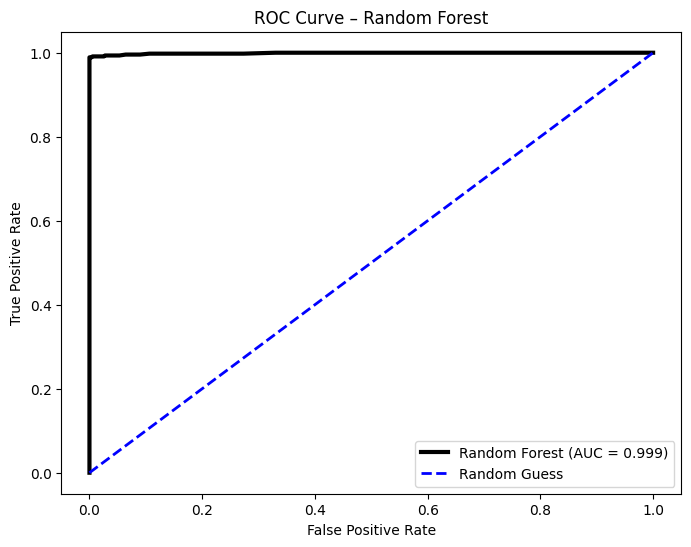

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute ROC values
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC curves

plt.figure(figsize=(8, 6))

# Random Forest ROC
plt.plot(fpr_rf, tpr_rf,color='black',linewidth=3,label=f"Random Forest (AUC = {auc_rf:.3f})")
# Random guess diagonal
plt.plot([0, 1], [0, 1],linestyle='--',color='blue',linewidth=2,label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest')
plt.legend()
plt.show()

#### KNEIGHBOURS CLASSIFICATION

In [54]:
# Import the KNeighboursClassifier model from the # sklearn library
from sklearn.neighbors import KNeighborsClassifier

# Create an instance of this model.
k_class = KNeighborsClassifier()

# Fit the model to the training data
k_class.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [55]:
# Use the trained model to predict the output class labels for the training set.
y_pred = k_class.predict(x_test)

In [56]:
# Predict churn probability for ROC-AUC
y_prob_knn = stream_class.predict_proba(x_test)[:, 1]

In [57]:
print("\nClassification Report for KN Classifier:\n", classification_report(y_test, y_pred ))


Classification Report for KN Classifier:
               precision    recall  f1-score   support

           0       0.84      0.89      0.87       545
           1       0.86      0.80      0.83       455

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000



In [58]:
print("K CLASSIFIERS RESULTS")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred ))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_knn))

K CLASSIFIERS RESULTS
Accuracy : 0.85
Precision: 0.8622327790973872
Recall   : 0.7978021978021979
F1-score : 0.8287671232876712
ROC-AUC  : 0.9989232785563061


<Figure size 1600x1200 with 0 Axes>

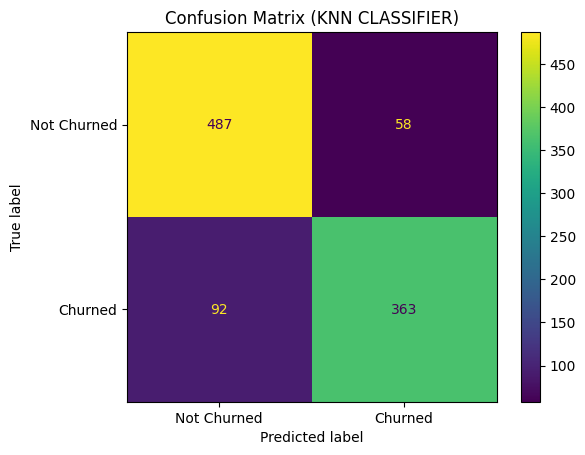

In [59]:
class_names = ['Not Churned', 'Churned']
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(dpi=200, figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred, display_labels=class_names)
plt.title('Confusion Matrix (KNN CLASSIFIER)')
plt.show()

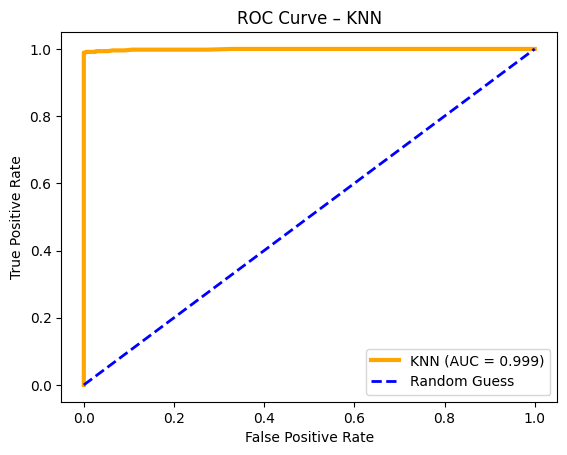

In [60]:

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assuming you already computed:
# y_test, y_pred_proba_rf, y_pred_proba_knn

# Compute ROC values
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)

# Plot ROC curves
plt.plot(fpr_knn, tpr_knn,color='orange',linewidth=3,label=f"KNN (AUC = {auc_knn:.3f})")
# Random guess line
plt.plot([0, 1], [0, 1],linestyle='--',color='blue',linewidth=2,label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – KNN')
plt.legend()
plt.show()


#### LOGISTICS REGRESSION

In [61]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression classifier
log_class = LogisticRegression(max_iter=2000, random_state=42)

# Train the model
log_class.fit(x_train, y_train)
# Predict class labels (0 or 1)
y_pred_log = log_class.predict(x_test)

# Predict probabilities for ROC / AUC (probability of class 1 = Churned)
y_prob_log = log_class.predict_proba(x_test)[:, 1]


In [62]:
print("\nClassification Report foe Logistics Regression:\n", classification_report(y_test, y_pred ))


Classification Report foe Logistics Regression:
               precision    recall  f1-score   support

           0       0.84      0.89      0.87       545
           1       0.86      0.80      0.83       455

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000



In [63]:
print("LOGISTICS REGRESSION RESULTS")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred ))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_knn))

LOGISTICS REGRESSION RESULTS
Accuracy : 0.85
Precision: 0.8622327790973872
Recall   : 0.7978021978021979
F1-score : 0.8287671232876712
ROC-AUC  : 0.9989232785563061


<Figure size 1600x1200 with 0 Axes>

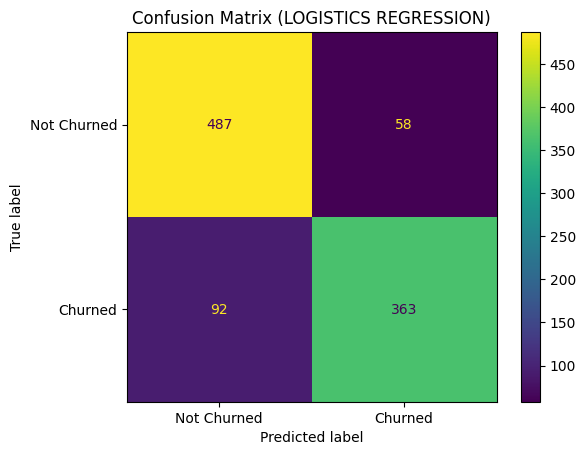

In [64]:
class_names = ['Not Churned', 'Churned']
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(dpi=200, figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred, display_labels=class_names)
plt.title('Confusion Matrix (LOGISTICS REGRESSION)')
plt.show()

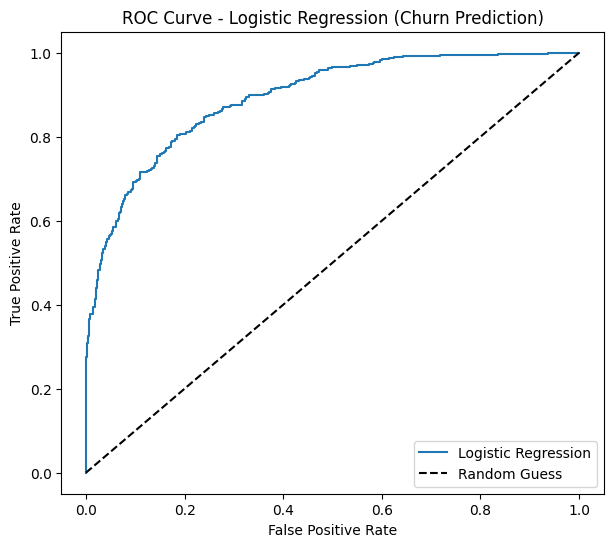

In [65]:
fpr, tpr, _ = roc_curve(y_test, y_prob_log)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Churn Prediction)")
plt.legend(loc="lower right")
plt.show()


In [66]:
# Feature names = numerical feature names + one-hot encoded categorical names
num_feature_names = num_feature
cat_feature_names = ohe.get_feature_names_out(cat_feature)

all_feature_names = list(num_feature_names) + list(cat_feature_names)

coef_df = pd.DataFrame({"Feature": all_feature_names,"Coefficient": log_class.coef_[0]})

# Sort by strongest positive (more churn) and strongest negative (less churn)
coef_df_sorted = coef_df.sort_values(by="Coefficient", ascending=False)

print("Top 10 features increasing churn probability:")
display(coef_df_sorted.head(10))

print("Top 10 features decreasing churn probability:")
display(coef_df_sorted.tail(10))



Top 10 features increasing churn probability:


,Feature,Coefficient
5,Last_Activity,1.309637
1,Subscription_Length,0.963798
4,Discount_Offered,0.343382
2,Support_Tickets_Raised,0.280051
10,Region_North,0.084260
15,Payment_Method_PayPal,0.028249
0,Age,0.014279
8,Gender_Male,0.003299
14,Payment_Method_Debit Card,-0.004035
12,Region_West,-0.022086


Top 10 features decreasing churn probability:


,Feature,Coefficient
0,Age,0.014279
8,Gender_Male,0.003299
14,Payment_Method_Debit Card,-0.004035
12,Region_West,-0.022086
11,Region_South,-0.123433
9,Region_East,-0.124235
7,Gender_Female,-0.188793
13,Payment_Method_Credit Card,-0.209708
3,Satisfaction_Score,-0.694615
6,Monthly_Spend,-1.686783




#### (G) K-MEANS CLUSTERING
Apply the k-Means clustering algorithm to identify different clusters in the streaming
service dataset. What is the optimal number of clusters (k) and why? Which features produce
the most meaningful clusters? Support your answer with visualizations and evaluation metrics.

In [67]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import AgglomerativeClustering


num_features = ["Age","Subscription_Length","Support_Tickets_Raised","Satisfaction_Score","Discount_Offered","Last_Activity","Monthly_Spend"] 

x_num = df[num_features]
from sklearn.preprocessing import StandardScaler

# Create an instance of the StandardScaler class
scale = StandardScaler()

# Fit the standard scaler to the input data that  we have in x.
scale.fit(x_num)

# Now apply the standard scaler transformation to the scaled feature.
x_scaled = scale.transform(x_num)

In [68]:
from sklearn.cluster import KMeans
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)
inertia

[35000.0,
 28412.274359192623,
 25930.249062927054,
 24030.726286664714,
 22710.567869256935,
 21276.95694482464,
 20247.96262605514,
 19349.41414287307,
 18589.057089933027,
 18062.036871063527]

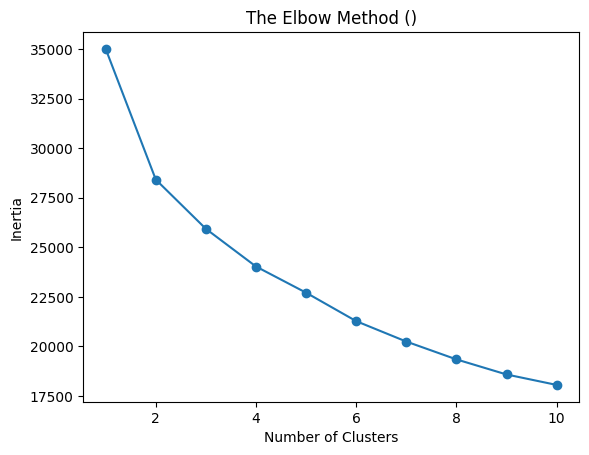

In [69]:
# create a plot of inertia versus k. 
plt.plot(range(1, 11), inertia, marker='o')

# Label both axes
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("The Elbow Method ()")

#plt.plot(range(1, 11),inertia, 'bx-')
plt.show()

This "elbow" at 3 tells us that 3 is the optimal number of clusters for this data.

In [70]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(x_scaled)

silhouette_score(x_scaled, labels)

# Fit the final model with 3 clusters
kmeans_new = KMeans(n_clusters=3, random_state=42)
cluster_labels_pred = kmeans_new.fit_predict(x_scaled)

# Calculate scores
db_score = davies_bouldin_score(x_scaled, cluster_labels_pred)
s_score = silhouette_score(x_scaled, cluster_labels_pred)

print("K-MEANS CLUSTERING:")
print(f"Davies-Bouldin Score: {db_score}")
print(f"Silhouette Score: {s_score}")


K-MEANS CLUSTERING:
Davies-Bouldin Score: 2.1585117864129537
Silhouette Score: 0.13232735451887848


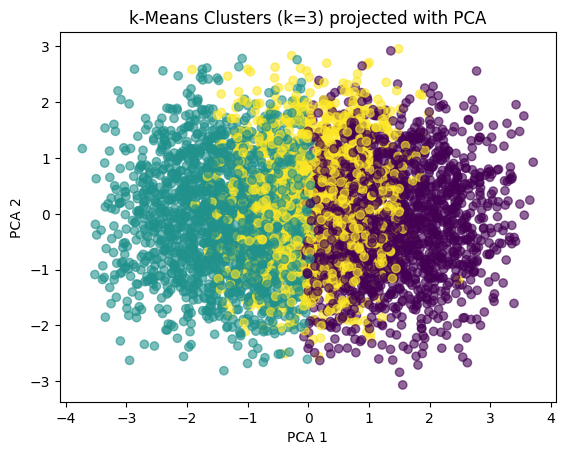

,Age,Subscription_Length,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend
Cluster,,,,,,,
0,43.468310,46.022300,1.849178,6.897887,13.110276,182.050469,55.600626
1,42.832966,25.684123,2.132304,2.830209,11.686538,175.075524,37.527512
2,44.433873,15.863023,2.111336,7.468961,12.653664,188.533063,47.365121


In [71]:
best_k = 3
kmeans_new = KMeans(n_clusters=3, random_state=42)
cluster_labels_pred = kmeans_new.fit_predict(x_scaled)

# PCA to 2D for plotting
pca = PCA(n_components=3, random_state=42)
x_2d = pca.fit_transform(x_scaled)

plt.figure()
plt.scatter(x_2d[:, 0], x_2d[:, 1], c=cluster_labels_pred, alpha=0.6)
plt.title(f"k-Means Clusters (k={best_k}) projected with PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

df_clustered = df.copy()
df_clustered["Cluster"] = cluster_labels_pred
df_clustered.groupby("Cluster")[num_features].mean()

#### (H) HIERARCHICAL CLUSTERING
Compare the k-Means clustering results from part (g) with another clustering algorithm
(e.g., Hierarchical Clustering or DBSCAN). Which algorithm provides the best segmentation
of customer behaviour, and why? Use evaluation metrics to justify your answer.

In [72]:
num_features = ["Age","Subscription_Length","Support_Tickets_Raised","Satisfaction_Score","Discount_Offered","Last_Activity","Monthly_Spend"] 

x_num = df[num_features]
from sklearn.preprocessing import StandardScaler

# Create an instance of the StandardScaler class
scale = StandardScaler()

# Fit the standard scaler to the input data that  we have in x.
scale.fit(x_num)

# Now apply the standard scaler transformation to the scaled feature.
x_scaled = scale.transform(x_num)


In [73]:
from sklearn.cluster import AgglomerativeClustering
agg_model = AgglomerativeClustering(n_clusters = 3, linkage = 'complete')
agg_labels_pred = agg_model.fit_predict(x_scaled)

In [74]:
# Fit the final model with 3 clusters
kmeans_new = KMeans(n_clusters=3, random_state=42)
agg_labels_pred = agg_model.fit_predict(x_scaled)

# Calculate scores
db_agg = davies_bouldin_score(x_scaled, agg_labels_pred)
s_agg = silhouette_score(x_scaled, agg_labels_pred)

print("HIERARCHICAL CLUSTERING:")
print(f"Hierarchical DB: {db_agg}")
print(f"Silhouette: {s_agg}")

HIERARCHICAL CLUSTERING:
Hierarchical DB: 2.56473136328064
Silhouette: 0.09170169723103902


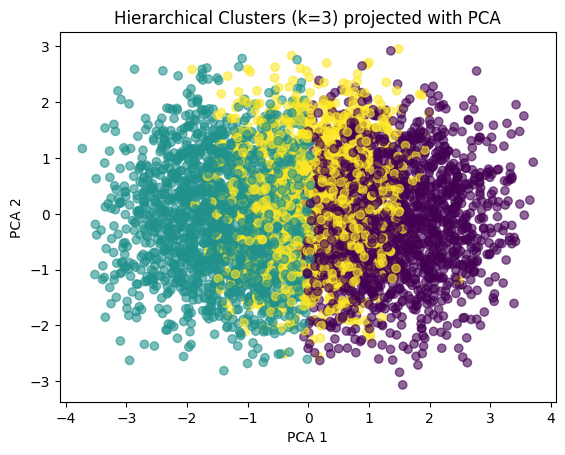

In [75]:
best_k = 3
kmeans_new = KMeans(n_clusters=3, random_state=42)
agg_labels_pred = agg_model.fit_predict(x_scaled)

# PCA to 2D for plotting
pca = PCA(n_components=3, random_state=42)
x_2d = pca.fit_transform(x_scaled)

plt.figure()
plt.scatter(x_2d[:, 0], x_2d[:, 1], c=cluster_labels_pred, alpha=0.6)
plt.title(f"Hierarchical Clusters (k={best_k}) projected with PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [76]:
df_clustered = df.copy()
df_clustered["Cluster"] = agg_labels_pred
df_clustered.groupby("Cluster")[num_features].mean()

,Age,Subscription_Length,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend
Cluster,,,,,,,
0,45.828377,33.532784,1.451093,6.460408,13.245002,178.933716,51.218143
1,40.657122,19.349486,2.218062,3.182819,11.451703,183.947871,36.326540
2,40.540732,33.740260,3.632822,6.600945,11.485242,185.674144,47.918416


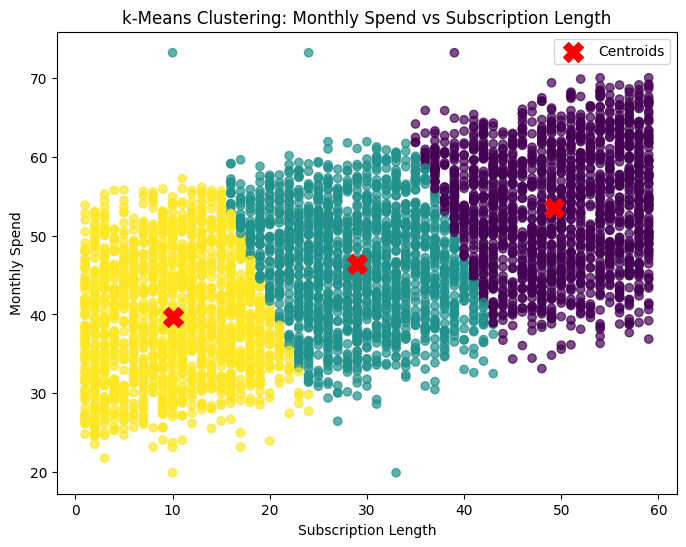

In [77]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select features for visualisation
X_vis = df[['Subscription_Length', 'Monthly_Spend']]

# Fit k-Means (k = 3)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_vis)

plt.figure(figsize=(8,6))
plt.scatter(X_vis['Subscription_Length'],X_vis['Monthly_Spend'],c=clusters,cmap='viridis',alpha=0.7)

plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],c='red',s=200,marker='X',label='Centroids')

plt.xlabel('Subscription Length')
plt.ylabel('Monthly Spend')
plt.title('k-Means Clustering: Monthly Spend vs Subscription Length')
plt.legend()
plt.show()
